In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [2]:
#pip install pandas

In [3]:
import pandas as pd

In [4]:
# conversions

def r_int_to_cm(r):
    return r*5.11e12
def m_int_to_g(M):
    return M*2e33
def t_int_to_s(t):
    return t*1e6
def v_int_to_cms(v):
    return v*5.11e6

In [118]:
data = pd.read_csv('2b_output.txt', sep=' ', header=None, names=range(7))
data.columns = ['m','x','y','z','vx','vy','vz']

In [119]:
print(data)

                m         x             y    z            vx            vy  \
0        2.000000       NaN           NaN  NaN           NaN           NaN   
1        0.145901       NaN           NaN  NaN           NaN           NaN   
2        0.000001  2.885119  8.657912e-02  0.0 -1.750972e-02  5.932336e-01   
3        1.000000 -0.000003 -8.657912e-08  0.0  1.750972e-08 -5.932336e-07   
4        2.000000       NaN           NaN  NaN           NaN           NaN   
...           ...       ...           ...  ...           ...           ...   
63195    1.000000 -0.000003  3.887953e-09  0.0 -7.862124e-10 -5.934957e-07   
63196    2.000000       NaN           NaN  NaN           NaN           NaN   
63197  158.138643       NaN           NaN  NaN           NaN           NaN   
63198    0.000001  2.885231  8.269280e-02  0.0 -1.672385e-02  5.932567e-01   
63199    1.000000 -0.000003 -8.269280e-08  0.0  1.672385e-08 -5.932567e-07   

        vz  
0      NaN  
1      NaN  
2      0.0  
3      0.0 

In [120]:
time_rows = data[data.index % 4 -1 == 0]
times = (time_rows['m'])

m1_rows = data[data.index % 4 -2 == 0]
m2_rows = data[data.index % 4 -3 == 0]

Text(0, 0.5, 'y [IU]')

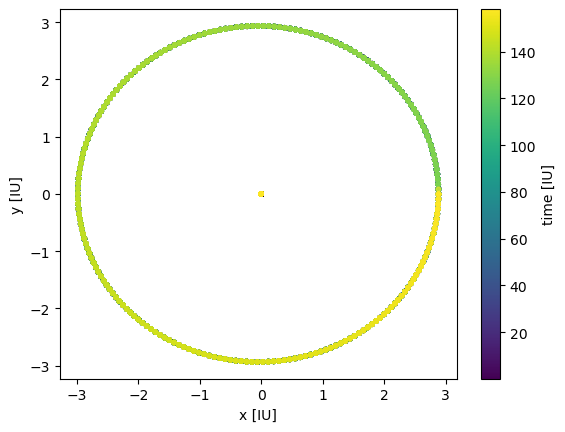

In [121]:
color = times
plt.scatter(m1_rows['x'],m1_rows['y'], c=color,  marker='.', alpha=0.5)
plt.scatter(m2_rows['x'],m2_rows['y'], c=color, marker='.', alpha=1)

plt.colorbar(label='time [IU]')
plt.xlabel('x [IU]')
plt.ylabel('y [IU]')


Text(0, 0.5, 'y [cm]')

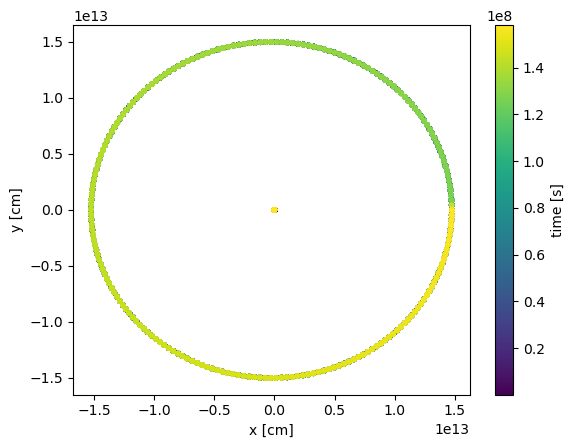

In [122]:
color = t_int_to_s(times)
plt.scatter(r_int_to_cm(m1_rows['x']),r_int_to_cm(m1_rows['y']), c=color,  marker='.', alpha=0.5)
plt.scatter(r_int_to_cm(m2_rows['x']),r_int_to_cm(m2_rows['y']), c=color, marker='.', alpha=1)

plt.colorbar(label='time [s]')
plt.xlabel('x [cm]')
plt.ylabel('y [cm]')

In [123]:
# comparison with analytical solution

In [124]:
x1 = np.array(m1_rows['x'])
x2 = np.array(m2_rows['x'])
y1 = np.array(m1_rows['y'])
y2 = np.array(m2_rows['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

print(aper, aapo)

2.886399216743765 2.984441883533465


In [125]:
M = m1_rows.iloc[0]['m'] + m2_rows.iloc[0]['m']
mu = (m1_rows.iloc[0]['m'] * m2_rows.iloc[0]['m'])/M

In [126]:
e = (-aper+aapo)/(aper+aapo)
print('e =',e)

a = (aper+aapo)/2
print('a =',a)

Etot = -M/(2*a)
print('Etot =',Etot)

e = 0.016699935344029346
a = 2.9354205501386152
Etot = -0.17033351489495743


In [127]:
def r(x1, y1, x2, y2):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2)

In [128]:
rad = r(x1, y1, x2, y2)
vrad = r(np.array(m1_rows['vx']),np.array(m1_rows['vy']),np.array(m2_rows['vx']),np.array(m2_rows['vy']))

In [129]:
EG = -M*mu/rad
print(EG)
EK = 0.5*mu*vrad**2
print(EK)

[-3.46449862e-07 -3.46449862e-07 -3.46449862e-07 ... -3.46452418e-07
 -3.46452418e-07 -3.46450089e-07]
[1.76116528e-07 1.76116528e-07 1.76116528e-07 ... 1.76119083e-07
 1.76119083e-07 1.76116754e-07]


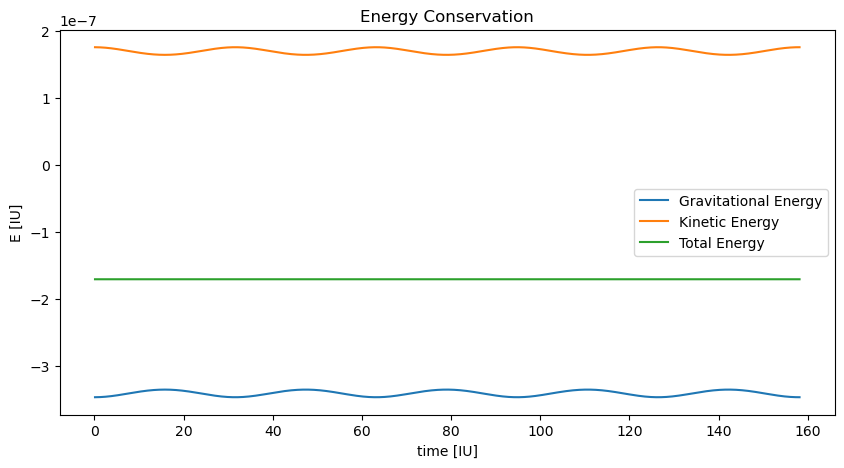

In [132]:
fig,ax = plt.subplots(1,1,figsize=(10,5))
plt.plot(times,EG,label='Gravitational Energy')
plt.plot(times,EK,label='Kinetic Energy')
plt.plot(times,EK+EG,label='Total Energy')
plt.xlabel('time [IU]')
plt.ylabel('E [IU]')
plt.title('Energy Conservation')
plt.legend()

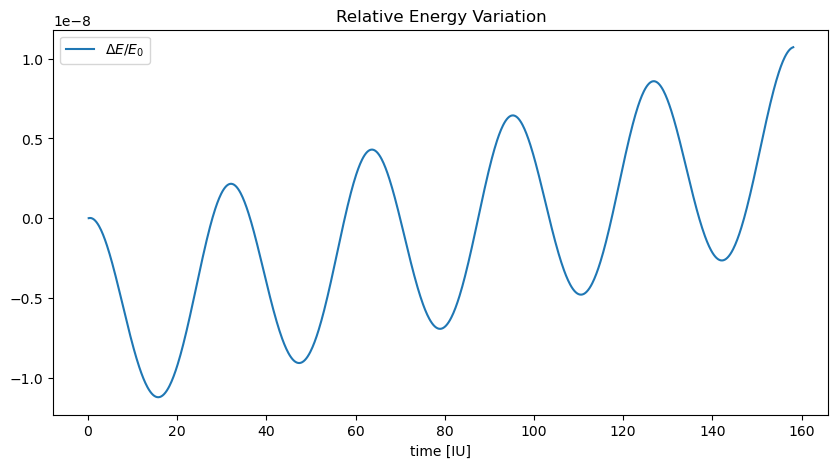

In [131]:
fig,ax = plt.subplots(1,1,figsize=(10,5))

plt.plot(times,(EK+EG-(EK[0]+EG[0]))/(EK[0]+EG[0]),label=r'$\Delta E/E_0$')
plt.xlabel('time [IU]')
plt.ylabel('')
plt.title('Relative Energy Variation')
plt.legend()